<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)


# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [5]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65447.000000,3.374000e+04,29659.000000,29325.000000,29394.000000,29412.000000,29451.000000,29449.000000,29457.000000,29457.000000,29451.000000,29446.000000,2.343500e+04,29126.000000
mean,32714.001528,2.963841e+145,11.467143,18.580460,7.521884,10.060515,24.342405,22.964440,20.277477,16.168883,10.955341,9.953610,8.615529e+04,6.935041
std,18893.063225,5.444117e+147,9.168610,25.966005,18.422399,21.833543,27.089272,27.017612,26.107934,24.844789,22.905963,21.775359,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16352.500000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32714.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49075.500000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.000000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [4]:
## Write your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [6]:
## Write your code here
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



In [15]:
missing_values_columns=df.columns[df.isnull().any()]


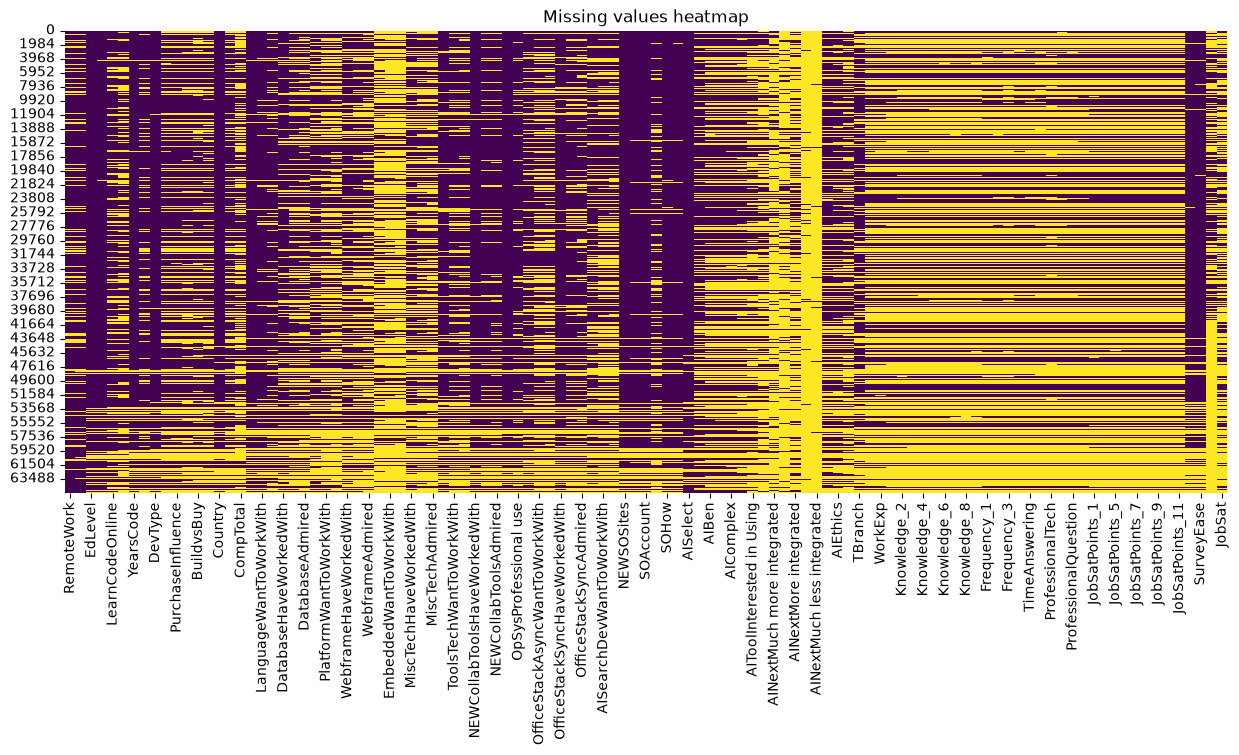

In [18]:
## Write your code here
plt.figure(figsize=(15,6))
sns.heatmap(df[missing_values_columns].isnull(),cbar=False,cmap="viridis")
plt.title("Missing values heatmap")

plt.show()






##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [19]:
## Write your code here
df["Employment"].isnull().sum()


np.int64(0)

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [20]:
## Write your code here
df["Employment"].mode()


0    Employed, full-time
Name: Employment, dtype: str

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [23]:
## Write your code here
df["Employment"].fillna(df["Employment"].mode()[0]
                       )

0                                      Employed, full-time
1                                      Employed, full-time
2                                      Employed, full-time
3                                       Student, full-time
4                                       Student, full-time
                               ...                        
65442                                   Student, full-time
65443                                  Employed, full-time
65444    Student, full-time;Not employed, but looking f...
65445                                  Employed, full-time
65446    Independent contractor, freelancer, or self-em...
Name: Employment, Length: 65447, dtype: str

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


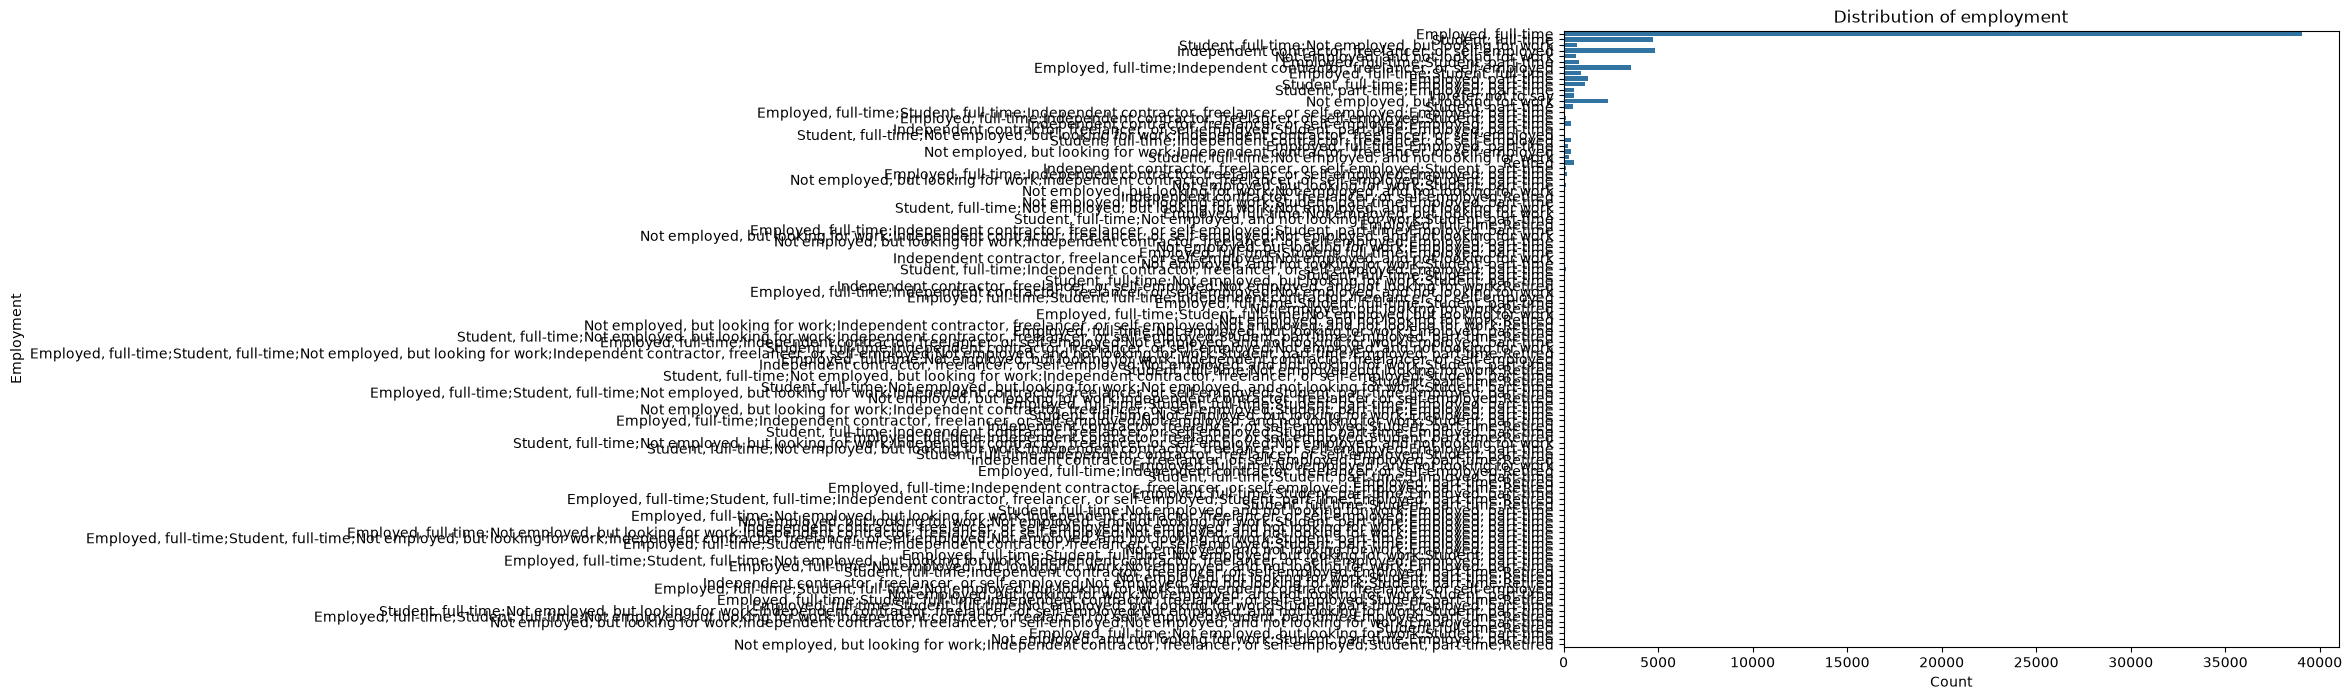

In [24]:
## Write your code here
plt.figure(figsize=(10,8))
sns.countplot(data=df,y="Employment")
plt.title("Distribution of employment")
plt.xlabel("Count")
plt.ylabel("Employment")
plt.show()

In [25]:
#grouping categories in employment for better visuals
df["Employment_Group"] = "Other"

df.loc[df["Employment"].str.contains("Employed", case=False, na=False), "Employment_Group"] = "Employed"
df.loc[df["Employment"].str.contains("Student", case=False, na=False), "Employment_Group"] = "Student"
df.loc[df["Employment"].str.contains("Independent contractor|freelancer", case=False, na=False), "Employment_Group"] = "Freelancer"
df.loc[df["Employment"].str.contains("Not employed", case=False, na=False), "Employment_Group"] = "Unemployed"


In [27]:
sns.countplot(data=df,y="Emplo
yment_Group")

SyntaxError: unterminated string literal (detected at line 1) (747863218.py, line 1)

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
